In [1]:
import os, glob
import torch
import nugraph as ng

torch.set_float32_matmul_precision("medium")

DATA_PATH = "/home/apaudel/NuGraph/scripts/merged1_Aug6_40k_pmtpmt_g4lepdir"

RUNS = [
    {
        "label": "Aug6 lepdir, no nexus",
        "run_name": "merged1_Aug18_MERGE_CERATI_NEXUS_on_Aug6_g4lepdir_no_new_features_pmtpmtfix_ep45_bs64_in8",
        "featext3d": False,
    },
    {
        "label": "Aug6 lepdir, nexus only",
        "run_name": "merged1_Aug18_MERGE_CERATI_NEXUS_on_Aug6_g4lepdir_nexusfeat_only_pmtpmtfix_ep45_bs64_in8_sp5",
        "featext3d": True,
    },
]

Data = ng.data.H5DataModule
Model = ng.models.NuGraph3

for r in RUNS:
    ckpts = glob.glob(f"/home/apaudel/NuGraph/logs/{r['run_name']}/**/*.ckpt", recursive=True)
    assert ckpts, f"No checkpoint found for {r['run_name']}"
    r["ckpt"] = max(ckpts, key=os.path.getmtime)
    print("\n", r["label"])
    print("checkpoint:", r["ckpt"])


 Aug6 lepdir, no nexus
checkpoint: /home/apaudel/NuGraph/logs/merged1_Aug18_MERGE_CERATI_NEXUS_on_Aug6_g4lepdir_no_new_features_pmtpmtfix_ep45_bs64_in8/version_0/checkpoints/epoch=44-step=21150.ckpt

 Aug6 lepdir, nexus only
checkpoint: /home/apaudel/NuGraph/logs/merged1_Aug18_MERGE_CERATI_NEXUS_on_Aug6_g4lepdir_nexusfeat_only_pmtpmtfix_ep45_bs64_in8_sp5/version_0/checkpoints/epoch=44-step=21150.ckpt



Aug6 lepdir, no nexus
event_classes: ['cc_nue', 'es_nue']
test events: 1672
featext3d: False
model.encoder.sp_net is None: True
PMT-PMT on: True

Counts:


,Pred ES,Pred CC
True CC,180,796
True ES,526,170



Row-normalized fractions:


,Pred ES,Pred CC
True CC,0.1844,0.8156
True ES,0.7557,0.2443



Overall accuracy = 0.7907
CC classified as CC = 0.8156
ES classified as ES = 0.7557


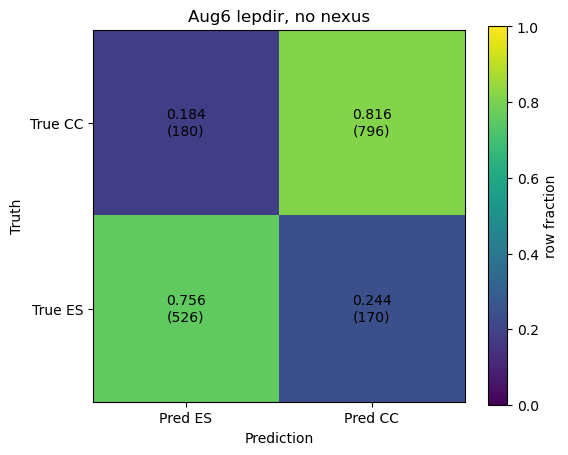


Aug6 lepdir, nexus only
event_classes: ['cc_nue', 'es_nue']
test events: 1672
featext3d: True
model.encoder.sp_net is None: False
PMT-PMT on: True

Counts:


,Pred ES,Pred CC
True CC,151,825
True ES,531,165



Row-normalized fractions:


,Pred ES,Pred CC
True CC,0.1547,0.8453
True ES,0.7629,0.2371



Overall accuracy = 0.8110
CC classified as CC = 0.8453
ES classified as ES = 0.7629


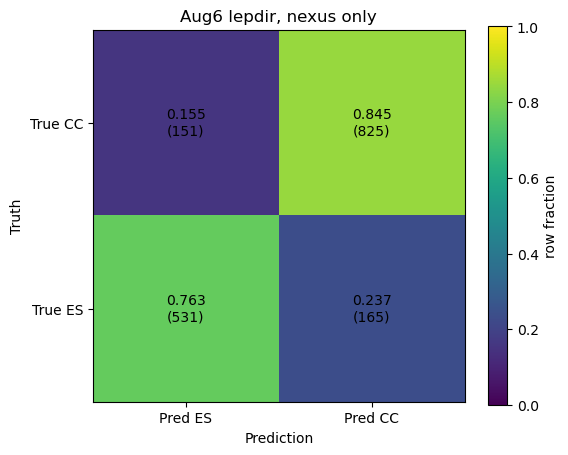


Summary:


,run,accuracy,CC classified as CC,ES classified as ES
0,"Aug6 lepdir, no nexus",0.7907,0.8156,0.7557
1,"Aug6 lepdir, nexus only",0.8110,0.8453,0.7629


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

def evaluate_run(run):
    print("\n" + "="*80)
    print(run["label"])
    print("="*80)

    nudata = Data(
        DATA_PATH,
        batch_size=64,
        num_workers=0,
        model=Model,
        shuffle="random",
        featext3d=run["featext3d"],
    )

    model = Model.load_from_checkpoint(run["ckpt"])
    model = model.to(device)
    model.eval()

    print("event_classes:", nudata.event_classes)
    print("test events:", len(nudata.test_dataset))
    print("featext3d:", run["featext3d"])
    print("model.encoder.sp_net is None:", model.encoder.sp_net is None)
    print("PMT-PMT on:", model.optical_net.use_pmt_pmt)

    ys, ps = [], []

    with torch.no_grad():
        for batch in nudata.test_dataloader():
            batch = batch.to(device)
            model(batch)

            y = batch["evt"].y.detach().cpu().view(-1)
            probs = batch["evt"].e.detach().cpu()
            pred = probs.argmax(dim=1)

            ys.append(y.numpy())
            ps.append(pred.numpy())

    y_true = np.concatenate(ys)
    y_pred = np.concatenate(ps)

    classes = list(nudata.event_classes)
    cc_idx = [i for i, c in enumerate(classes) if "cc" in c.lower()][0]
    es_idx = [i for i, c in enumerate(classes) if "es" in c.lower()][0]

    # Y axis truth: CC, ES
    # X axis prediction: ES, CC
    row_order = [cc_idx, es_idx]
    col_order = [es_idx, cc_idx]
    row_names = ["True CC", "True ES"]
    col_names = ["Pred ES", "Pred CC"]

    cm = np.zeros((2, 2), dtype=int)

    for i, yt in enumerate(row_order):
        for j, yp in enumerate(col_order):
            cm[i, j] = np.sum((y_true == yt) & (y_pred == yp))

    cm_frac = cm / cm.sum(axis=1, keepdims=True)

    df_counts = pd.DataFrame(cm, index=row_names, columns=col_names)
    df_frac = pd.DataFrame(cm_frac, index=row_names, columns=col_names)

    print("\nCounts:")
    display(df_counts)

    print("\nRow-normalized fractions:")
    display(df_frac.round(4))

    acc = np.mean(y_true == y_pred)
    cc_eff = cm[0, 1] / cm[0].sum()
    es_eff = cm[1, 0] / cm[1].sum()

    print(f"\nOverall accuracy = {acc:.4f}")
    print(f"CC classified as CC = {cc_eff:.4f}")
    print(f"ES classified as ES = {es_eff:.4f}")

    plt.figure(figsize=(5.8, 4.7))
    plt.imshow(cm_frac, vmin=0, vmax=1)
    plt.xticks(range(2), col_names)
    plt.yticks(range(2), row_names)
    plt.colorbar(label="row fraction")

    for i in range(2):
        for j in range(2):
            plt.text(
                j, i,
                f"{cm_frac[i,j]:.3f}\n({cm[i,j]})",
                ha="center",
                va="center",
            )

    plt.title(run["label"])
    plt.xlabel("Prediction")
    plt.ylabel("Truth")
    plt.tight_layout()
    plt.show()

    return {
        "run": run["label"],
        "accuracy": acc,
        "cc_eff": cc_eff,
        "es_eff": es_eff,
        "cm": cm,
        "cm_frac": cm_frac,
    }

results = [evaluate_run(r) for r in RUNS]

summary = pd.DataFrame([
    {
        "run": r["run"],
        "accuracy": r["accuracy"],
        "CC classified as CC": r["cc_eff"],
        "ES classified as ES": r["es_eff"],
    }
    for r in results
])

print("\nSummary:")
display(summary.round(4))